In [44]:
import numpy as np

import bot
import state
import physics
import presets
import nn
import scoring
import curling_nn
from constants import center_of_target_house, house_outer_circle_radius, STONE_RADIUS_M
import dataset


import logging

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
neural_network = curling_nn.ValueNetwork(seed=0, num_stones_per_side=5)
loss_function = nn.SoftmaxCrossEntropyLoss()

In [46]:
# TODO: training data should have throws from both teams
seed_states = presets.random_sheet_states(
    team1=5,
    team2=4,
    # TODO: use grid for better training data? maybe pick out best throws
    num_sims=200,
)
num_stones_per_side = 5

throws, states = bot.RandomThrows(
    rng=np.random.default_rng(0), n_throws_to_generate=200
).get_throws_for_num_sims(team=1, sheet_states=seed_states)

final_states = physics.run_until_stopping(
    sheet_states=state.add_stones_from_throws(states, throws)
)
final_scores = scoring.get_net_score_for_team(final_states, 0)

data = curling_nn.InputFeatures.create_score_match_dataset_from_sheet_states(
    states, throws, final_scores, num_stones_per_side
)

In [47]:
data, validation_data = data.partition(0.2, seed=0)

## categorical score predictor

In [48]:
losses = []
val_losses = []
num_points_per_batch = 100
num_iters = 10

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )
    val_losses.append(
        neural_network.get_average_loss_batched(
            validation_data.input_features, validation_data.answers, loss_function
        )
    )

In [22]:
validation_pred = nn.softmax(neural_network.run(validation_data.input_features[:,:,None]))

In [42]:
validation_r2 = (
    1
    - ((validation_data.answers - .15 * validation_pred[:, :, 0]) ** 2).sum()
    / (validation_data.answers**2).sum()
)

In [43]:
validation_r2

np.float64(0.047206636380555445)

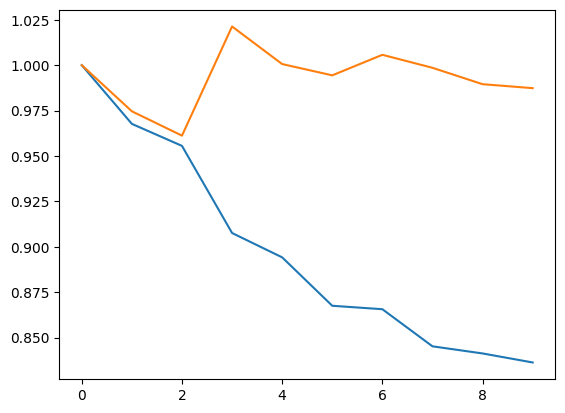

In [51]:
plt.plot(np.array(losses) / losses[0])
plt.plot(np.array(val_losses) / val_losses[0])

In [26]:
validation_loss = neural_network.get_average_loss_batched(
            validation_data.input_features, validation_data.answers, loss_function
        )
print(validation_loss)

2.743967596317851


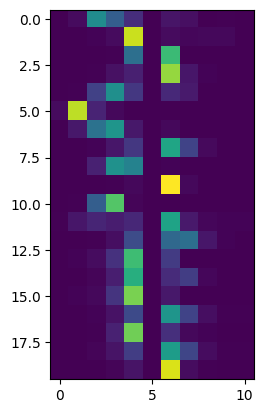

In [28]:
plt.imshow(validation_pred[:20,:,0])

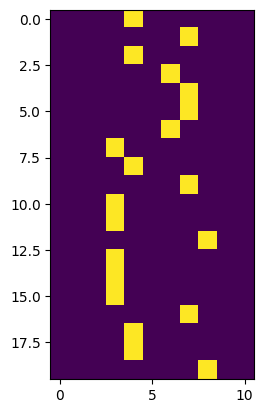

In [29]:
plt.imshow(validation_data.answers[:20,:])

## NEXT UP: predicting from second to last state